In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')
plt.rcParams['font.sans-serif'] = ['SimHei']   # 支持中文显示（可选）
plt.rcParams['figure.dpi'] = 120

print("✅ 所有库导入成功")

✅ 所有库导入成功


In [2]:
df = pd.read_excel('Online Retail.xlsx', dtype={'CustomerID': str})
print(f"数据维度：{df.shape}")
df.head()

数据维度：(541909, 8)


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom


In [3]:
print("=== 基本信息 ===")
print(df.info())

print("\n=== 缺失值统计 ===")
print(df.isnull().sum())

print("\n=== 数值列描述性统计 ===")
df[['Quantity', 'UnitPrice']].describe()

=== 基本信息 ===
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    541909 non-null  object        
 1   StockCode    541909 non-null  object        
 2   Description  540455 non-null  object        
 3   Quantity     541909 non-null  int64         
 4   InvoiceDate  541909 non-null  datetime64[ns]
 5   UnitPrice    541909 non-null  float64       
 6   CustomerID   406829 non-null  object        
 7   Country      541909 non-null  object        
dtypes: datetime64[ns](1), float64(1), int64(1), object(5)
memory usage: 33.1+ MB
None

=== 缺失值统计 ===
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

=== 数值列描述性统计 ===


,Quantity,UnitPrice
count,541909.000000,541909.000000
mean,9.552250,4.611114
std,218.081158,96.759853
min,-80995.000000,-11062.060000
25%,1.000000,1.250000
50%,3.000000,2.080000
75%,10.000000,4.130000
max,80995.000000,38970.000000


In [4]:
print(f"清洗前：{df.shape[0]} 行")

# 1. 删除没有 CustomerID 的行（无法做用户分析）
df = df.dropna(subset=['CustomerID'])

# 2. 删除退款订单（InvoiceNo 以 C 开头）
df = df[~df['InvoiceNo'].astype(str).str.startswith('C')]

# 3. 删除 Quantity 或 UnitPrice 为负数/零的异常行
df = df[(df['Quantity'] > 0) & (df['UnitPrice'] > 0)]

# 4. 新增"消费金额"列
df['TotalPrice'] = df['Quantity'] * df['UnitPrice']

# 5. 确保日期格式正确
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print(f"清洗后：{df.shape[0]} 行")
print(f"共删除：{541909 - df.shape[0]} 行异常数据")
df.head()

清洗前：541909 行
清洗后：397884 行
共删除：144025 行异常数据


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,TotalPrice
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850,United Kingdom,15.30
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850,United Kingdom,22.00
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850,United Kingdom,20.34


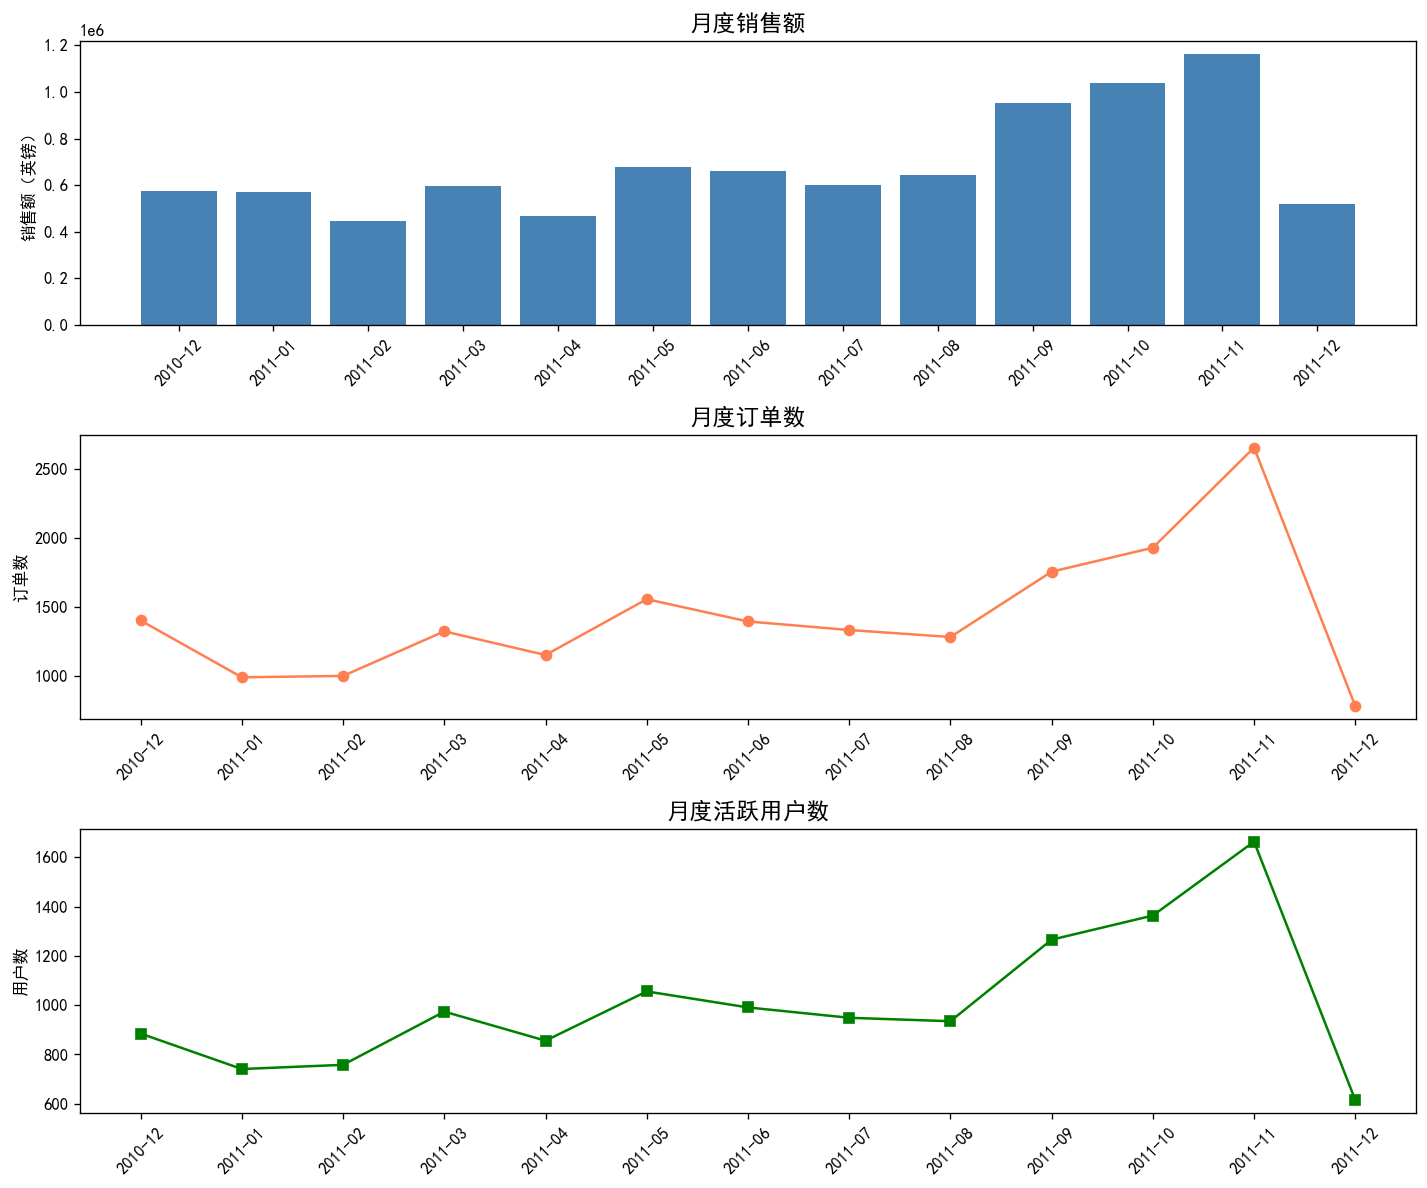

✅ 图已保存为 monthly_sales.png


In [5]:
# 提取年月
df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_sales = df.groupby('YearMonth').agg(
    销售额=('TotalPrice', 'sum'),
    订单数=('InvoiceNo', 'nunique'),
    用户数=('CustomerID', 'nunique')
).reset_index()

monthly_sales['YearMonth'] = monthly_sales['YearMonth'].astype(str)

# 画图
fig, axes = plt.subplots(3, 1, figsize=(12, 10))

axes[0].bar(monthly_sales['YearMonth'], monthly_sales['销售额'], color='steelblue')
axes[0].set_title('月度销售额', fontsize=14)
axes[0].set_ylabel('销售额（英镑）')
axes[0].tick_params(axis='x', rotation=45)

axes[1].plot(monthly_sales['YearMonth'], monthly_sales['订单数'], marker='o', color='coral')
axes[1].set_title('月度订单数', fontsize=14)
axes[1].set_ylabel('订单数')
axes[1].tick_params(axis='x', rotation=45)

axes[2].plot(monthly_sales['YearMonth'], monthly_sales['用户数'], marker='s', color='green')
axes[2].set_title('月度活跃用户数', fontsize=14)
axes[2].set_ylabel('用户数')
axes[2].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('monthly_sales.png', bbox_inches='tight')
plt.show()
print("✅ 图已保存为 monthly_sales.png")

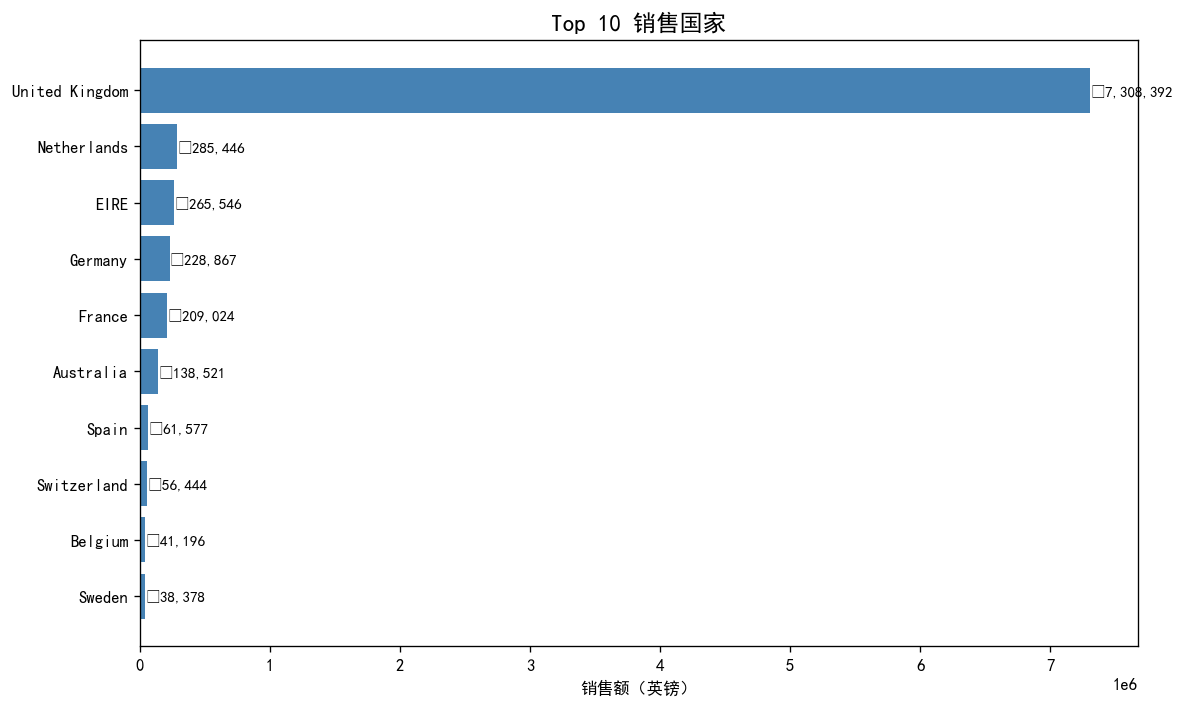

In [6]:
country_sales = df.groupby('Country')['TotalPrice'].sum().sort_values(ascending=False)

# 去掉本土(UK)看海外，或直接展示Top10
top10_country = country_sales.head(10)

plt.figure(figsize=(10, 6))
bars = plt.barh(top10_country.index[::-1], top10_country.values[::-1], color='steelblue')
plt.xlabel('销售额（英镑）')
plt.title('Top 10 销售国家', fontsize=14)

# 在条形右侧显示数值
for bar, val in zip(bars, top10_country.values[::-1]):
    plt.text(val + 500, bar.get_y() + bar.get_height()/2,
             f'£{val:,.0f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig('top10_country.png', bbox_inches='tight')
plt.show()

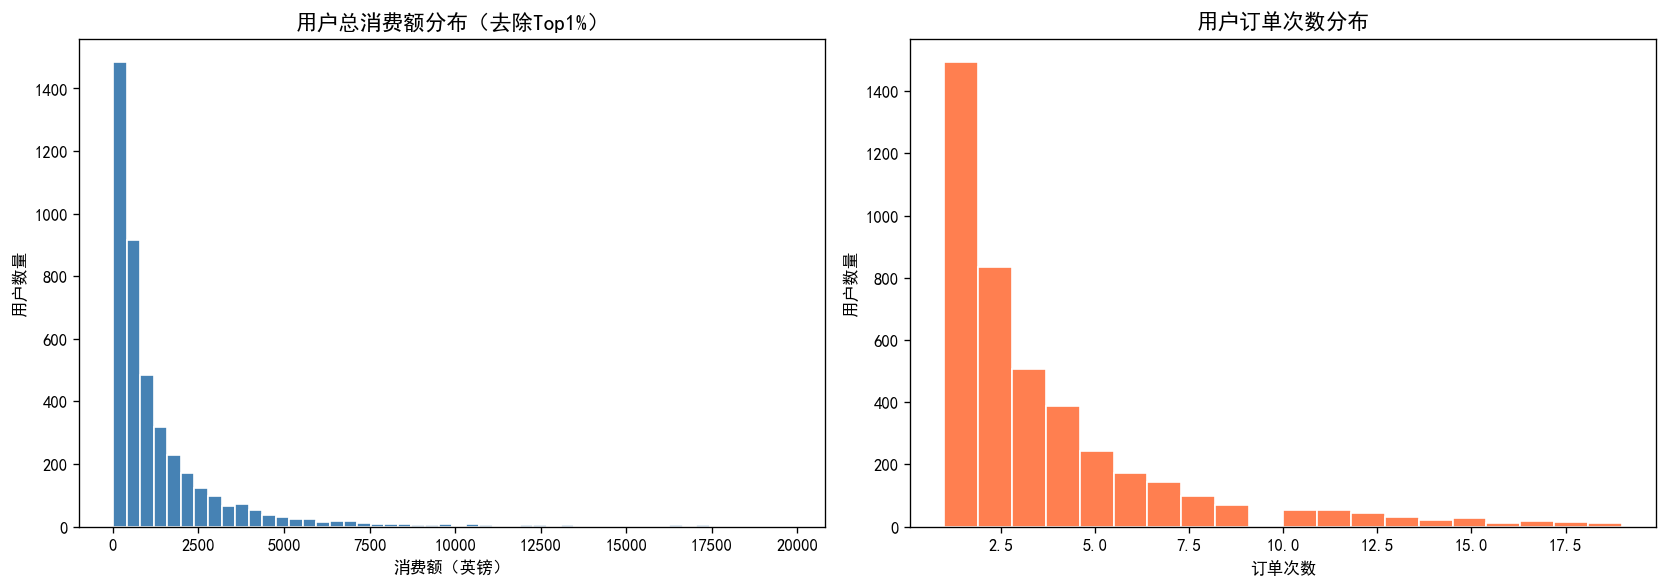

总用户数：4338
平均消费额：£2054.27
平均订单次数：4.3 次


In [7]:
user_stats = df.groupby('CustomerID').agg(
    总消费额=('TotalPrice', 'sum'),
    订单次数=('InvoiceNo', 'nunique'),
    购买商品种数=('StockCode', 'nunique')
).reset_index()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 消费额分布（去掉极端值方便观察）
q99 = user_stats['总消费额'].quantile(0.99)
axes[0].hist(user_stats[user_stats['总消费额'] < q99]['总消费额'],
             bins=50, color='steelblue', edgecolor='white')
axes[0].set_title('用户总消费额分布（去除Top1%）', fontsize=13)
axes[0].set_xlabel('消费额（英镑）')
axes[0].set_ylabel('用户数量')

# 订单次数分布
axes[1].hist(user_stats[user_stats['订单次数'] < 20]['订单次数'],
             bins=20, color='coral', edgecolor='white')
axes[1].set_title('用户订单次数分布', fontsize=13)
axes[1].set_xlabel('订单次数')
axes[1].set_ylabel('用户数量')

plt.tight_layout()
plt.savefig('user_distribution.png', bbox_inches='tight')
plt.show()

print(f"总用户数：{len(user_stats)}")
print(f"平均消费额：£{user_stats['总消费额'].mean():.2f}")
print(f"平均订单次数：{user_stats['订单次数'].mean():.1f} 次")

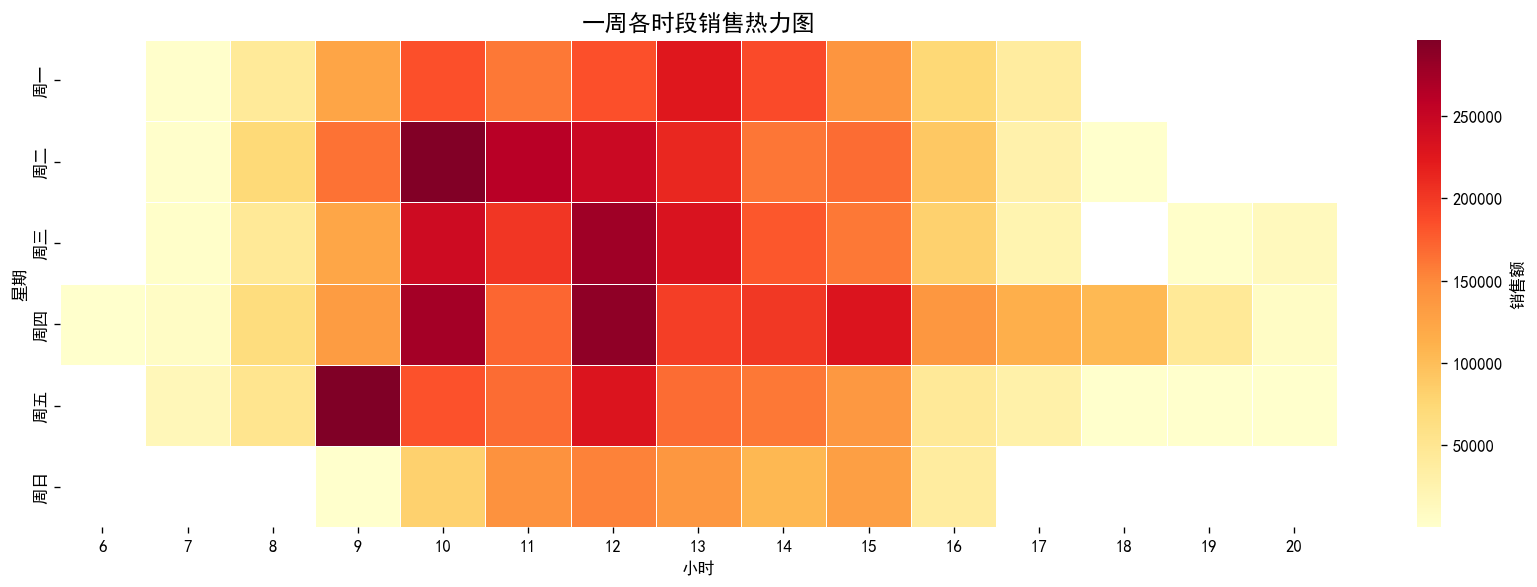

In [9]:
df['weekday'] = df['InvoiceDate'].dt.dayofweek   # 0=周一
df['hour'] = df['InvoiceDate'].dt.hour

heatmap_data = df.groupby(['weekday', 'hour'])['TotalPrice'].sum().unstack()

# 动态生成标签，只保留数据中实际存在的星期
weekday_names = {0:'周一', 1:'周二', 2:'周三', 3:'周四', 4:'周五', 5:'周六', 6:'周日'}
heatmap_data.index = [weekday_names[i] for i in heatmap_data.index]

plt.figure(figsize=(14, 5))
sns.heatmap(heatmap_data, cmap='YlOrRd', fmt='.0f',
            linewidths=0.3, cbar_kws={'label': '销售额'})
plt.title('一周各时段销售热力图', fontsize=14)
plt.xlabel('小时')
plt.ylabel('星期')
plt.tight_layout()
plt.savefig('heatmap.png', bbox_inches='tight')
plt.show()

In [10]:
# 以数据集中最后一天的次日作为"今天"
snapshot_date = df['InvoiceDate'].max() + pd.Timedelta(days=1)
print(f"参考日期：{snapshot_date.date()}")

rfm = df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot_date - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

print(rfm.describe().round(2))
rfm.head()

参考日期：2011-12-10
       Recency  Frequency   Monetary
count  4338.00    4338.00    4338.00
mean     92.54       4.27    2054.27
std     100.01       7.70    8989.23
min       1.00       1.00       3.75
25%      18.00       1.00     307.41
50%      51.00       2.00     674.48
75%     142.00       5.00    1661.74
max     374.00     209.00  280206.02


,CustomerID,Recency,Frequency,Monetary
0,12346,326,1,77183.60
1,12347,2,7,4310.00
2,12348,75,4,1797.24
3,12349,19,1,1757.55
4,12350,310,1,334.40


In [11]:
# 用五分位数打分，R越小越好（反向），F/M越大越好
rfm['R_score'] = pd.qcut(rfm['Recency'], q=5, labels=[5,4,3,2,1])
rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'), q=5, labels=[1,2,3,4,5])
rfm['M_score'] = pd.qcut(rfm['Monetary'], q=5, labels=[1,2,3,4,5])

rfm['RFM_Score'] = (rfm['R_score'].astype(int)
                  + rfm['F_score'].astype(int)
                  + rfm['M_score'].astype(int))

print(rfm[['R_score','F_score','M_score','RFM_Score']].describe())

         RFM_Score
count  4338.000000
mean      9.015445
std       3.591229
min       3.000000
25%       6.000000
50%       9.000000
75%      12.000000
max      15.000000


In [12]:
def segment_user(row):
    r, f, m = int(row['R_score']), int(row['F_score']), int(row['M_score'])
    if r >= 4 and f >= 4 and m >= 4:
        return '💎 高价值用户'
    elif r >= 3 and f >= 3:
        return '🌟 潜力用户'
    elif r >= 4 and f <= 2:
        return '🆕 新用户'
    elif r <= 2 and f >= 3:
        return '😴 流失预警用户'
    elif r <= 2 and f <= 2:
        return '❌ 流失用户'
    else:
        return '📊 普通用户'

rfm['Segment'] = rfm.apply(segment_user, axis=1)

segment_counts = rfm['Segment'].value_counts()
print(segment_counts)

Segment
❌ 流失用户      1065
🌟 潜力用户       998
💎 高价值用户      962
😴 流失预警用户     643
📊 普通用户       351
🆕 新用户        319
Name: count, dtype: int64


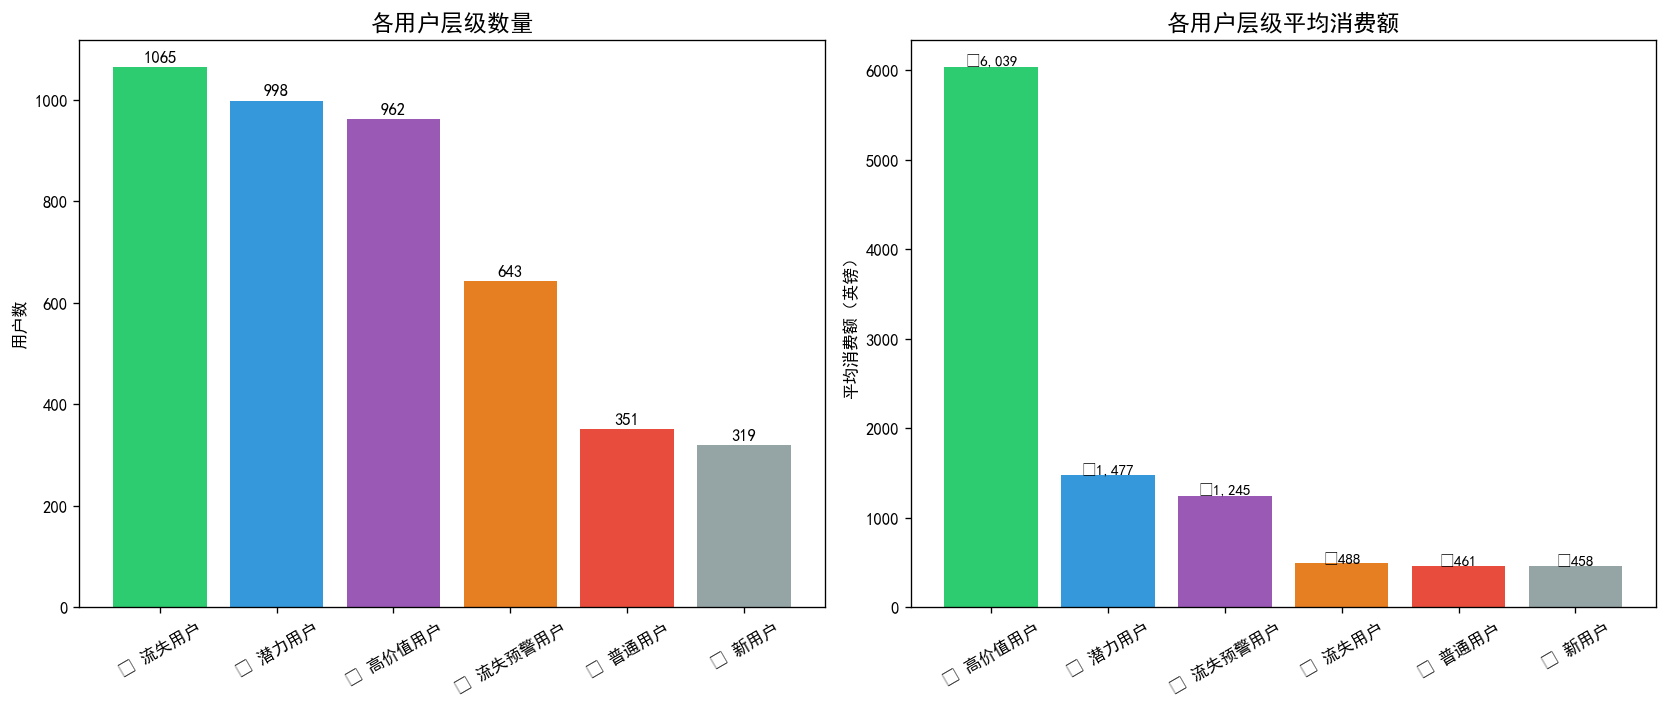

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# 左图：各分层用户数量
colors = ['#2ecc71','#3498db','#9b59b6','#e67e22','#e74c3c','#95a5a6']
axes[0].bar(segment_counts.index, segment_counts.values, color=colors)
axes[0].set_title('各用户层级数量', fontsize=14)
axes[0].set_ylabel('用户数')
axes[0].tick_params(axis='x', rotation=30)
for i, v in enumerate(segment_counts.values):
    axes[0].text(i, v + 10, str(v), ha='center', fontsize=10)

# 右图：各分层平均消费额
segment_monetary = rfm.groupby('Segment')['Monetary'].mean().sort_values(ascending=False)
axes[1].bar(segment_monetary.index, segment_monetary.values, color=colors)
axes[1].set_title('各用户层级平均消费额', fontsize=14)
axes[1].set_ylabel('平均消费额（英镑）')
axes[1].tick_params(axis='x', rotation=30)
for i, v in enumerate(segment_monetary.values):
    axes[1].text(i, v + 20, f'£{v:,.0f}', ha='center', fontsize=9)

plt.tight_layout()
plt.savefig('rfm_segments.png', bbox_inches='tight')
plt.show()

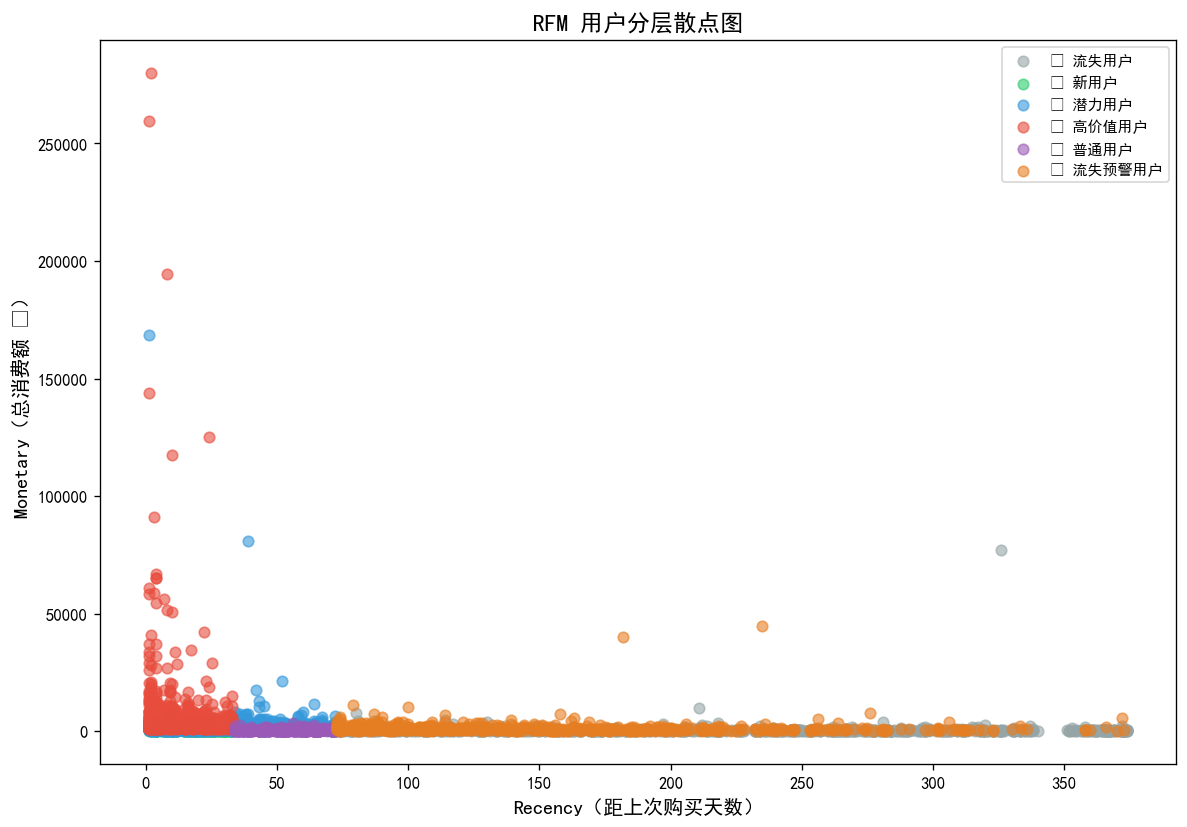

In [14]:
plt.figure(figsize=(10, 7))

segment_list = rfm['Segment'].unique()
color_map = {
    '💎 高价值用户': '#e74c3c',
    '🌟 潜力用户':   '#3498db',
    '🆕 新用户':     '#2ecc71',
    '😴 流失预警用户':'#e67e22',
    '❌ 流失用户':   '#95a5a6',
    '📊 普通用户':   '#9b59b6'
}

for seg, group in rfm.groupby('Segment'):
    plt.scatter(group['Recency'], group['Monetary'],
                label=seg, alpha=0.6, s=40,
                color=color_map.get(seg, 'gray'))

plt.xlabel('Recency（距上次购买天数）', fontsize=12)
plt.ylabel('Monetary（总消费额 £）', fontsize=12)
plt.title('RFM 用户分层散点图', fontsize=14)
plt.legend(loc='upper right', fontsize=9)
plt.tight_layout()
plt.savefig('rfm_scatter.png', bbox_inches='tight')
plt.show()

In [19]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.metrics import classification_report, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

# 按时间切分：前10个月为训练期，后2个月为观察期
split_date = pd.Timestamp('2011-10-01')
train_df = df[df['InvoiceDate'] < split_date]
observe_df = df[df['InvoiceDate'] >= split_date]

# 训练期计算 RFM 特征
snapshot = split_date
rfm_train = train_df.groupby('CustomerID').agg(
    Recency=('InvoiceDate', lambda x: (snapshot - x.max()).days),
    Frequency=('InvoiceNo', 'nunique'),
    Monetary=('TotalPrice', 'sum')
).reset_index()

# 观察期：是否有购买行为 = 标签
active_in_observe = observe_df['CustomerID'].unique()
rfm_train['is_churn'] = (~rfm_train['CustomerID'].isin(active_in_observe)).astype(int)

print(f"训练期用户数：{len(rfm_train)}")
print(f"流失用户：{rfm_train['is_churn'].sum()} 人")
print(f"活跃用户：{(rfm_train['is_churn']==0).sum()} 人")

X = rfm_train[['Recency', 'Frequency', 'Monetary']]
y = rfm_train['is_churn']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"\n训练集：{len(X_train)} 条，测试集：{len(X_test)} 条")

训练期用户数：3616
流失用户：1778 人
活跃用户：1838 人

训练集：2892 条，测试集：724 条


In [20]:
model = GradientBoostingClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=4,
    random_state=42
)

model.fit(X_train_scaled, y_train)
y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

print("=== 模型评估报告 ===")
print(classification_report(y_test, y_pred, target_names=['活跃用户','流失用户']))
print(f"AUC-ROC 得分：{roc_auc_score(y_test, y_prob):.4f}")

=== 模型评估报告 ===
              precision    recall  f1-score   support

        活跃用户       0.68      0.65      0.66       368
        流失用户       0.65      0.69      0.67       356

    accuracy                           0.67       724
   macro avg       0.67      0.67      0.67       724
weighted avg       0.67      0.67      0.67       724

AUC-ROC 得分：0.7343


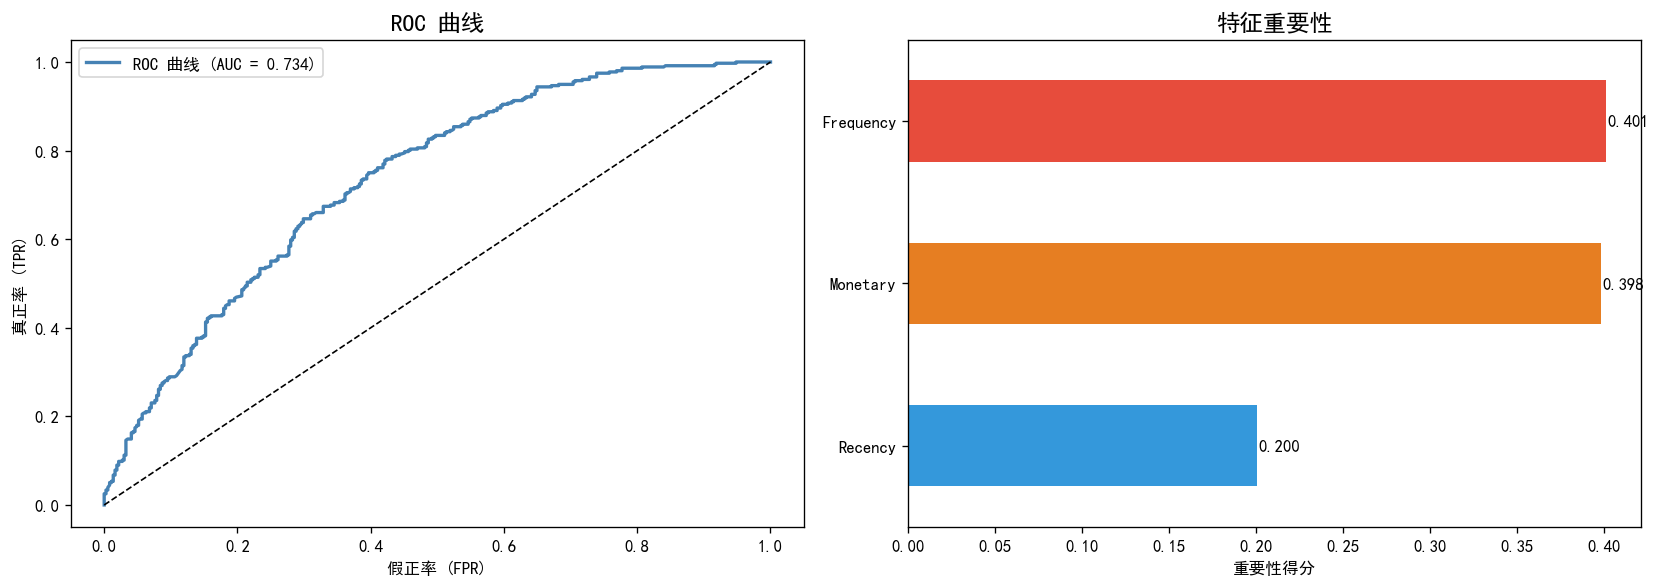

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 左图：ROC 曲线
fpr, tpr, _ = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)
axes[0].plot(fpr, tpr, color='steelblue', lw=2,
             label=f'ROC 曲线 (AUC = {auc_score:.3f})')
axes[0].plot([0,1],[0,1], 'k--', lw=1)
axes[0].set_xlabel('假正率 (FPR)')
axes[0].set_ylabel('真正率 (TPR)')
axes[0].set_title('ROC 曲线', fontsize=14)
axes[0].legend()

# 右图：特征重要性
feat_importance = pd.Series(model.feature_importances_,
                             index=['Recency','Frequency','Monetary'])
feat_importance.sort_values().plot(kind='barh', ax=axes[1],
                                    color=['#3498db','#e67e22','#e74c3c'])
axes[1].set_title('特征重要性', fontsize=14)
axes[1].set_xlabel('重要性得分')
for i, v in enumerate(feat_importance.sort_values().values):
    axes[1].text(v + 0.001, i, f'{v:.3f}', va='center')

plt.tight_layout()
plt.savefig('model_results.png', bbox_inches='tight')
plt.show()

In [24]:
# 用 rfm_train 替代 rfm，因为模型是基于训练期数据训练的
rfm_train['流失概率'] = model.predict_proba(scaler.transform(X))[:, 1]

# 高风险但还未完全流失的用户（最值得运营干预）
high_risk = rfm_train[
    (rfm_train['流失概率'] > 0.7) & (rfm_train['Recency'] <= 90)
].sort_values('流失概率', ascending=False)

print(f"高流失风险用户（仍活跃）：{len(high_risk)} 人")
print("\n前10名高风险用户：")
high_risk[['CustomerID','Recency','Frequency','Monetary','流失概率']].head(10)

高流失风险用户（仍活跃）：109 人

前10名高风险用户：


,CustomerID,Recency,Frequency,Monetary,流失概率
2539,16468,4,1,74.90,0.925947
1959,15504,11,1,52.83,0.921652
3215,17628,11,1,75.75,0.920763
2102,15744,7,1,34.80,0.905537
2019,15603,8,1,48.48,0.900572
2784,16878,14,1,13.30,0.897147
503,13130,24,1,64.00,0.893573
557,13218,57,1,62.64,0.889184
543,13194,65,1,60.70,0.873068
480,13095,0,1,74.40,0.872172
